# comp_impact

Notebook to figure out the function

-> into source

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
## Imports

import sys
sys.path.append("..") # Adds the project root to the path

In [4]:
from src.data_exposure import get_exposure
from src.data_hazard import get_haz_dict
from src.data_insurance import get_insurance

In [24]:
haz_dict = get_haz_dict()
haz_list = list(haz_dict.keys())

exposure = get_exposure(hazard_types=haz_list)

/Users/arvedluetzen/.pyenv/versions/miniforge3-latest/envs/eth-fs2026-praktikum/lib/python3.12/site-packages/climada/hazard/io.py:696: UserWarning: Not all values are of type <class 'str'>. Casting values.
  warnings.warn(


In [34]:
from copy import deepcopy
from climada.entity import Exposures

exposure_eigen_gdf = deepcopy(exposure.gdf)

exposure_eigen_gdf["value"] = 1

exposure_eigen_poly = Exposures(exposure_eigen_gdf)

In [47]:
exposure_eigen_poly.gdf

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,impf_WS,geometry
0,01,Ain,Auvergne-Rhône-Alpes,1,5762.4,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ..."
1,02,Aisne,Hauts-de-France,1,7361.7,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ..."
2,03,Allier,Auvergne-Rhône-Alpes,1,7340.1,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ..."
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,1,6925.2,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6..."
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,1,5548.7,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ..."
...,...,...,...,...,...,...,...
91,91,Essonne,Île-de-France,1,1804.4,1,"POLYGON ((2.58407 48.67715, 2.58038 48.68948, ..."
92,92,Hauts-de-Seine,Île-de-France,1,175.6,1,"POLYGON ((2.33598 48.93158, 2.33491 48.94154, ..."
93,93,Seine-Saint-Denis,Île-de-France,1,236.2,1,"POLYGON ((2.6026 48.92936, 2.6024 48.93532, 2...."
94,94,Val-de-Marne,Île-de-France,1,245.0,1,"POLYGON ((2.61482 48.76112, 2.60645 48.77333, ..."


In [74]:
import climada.util.lines_polys_handler as u_lp
import numpy as np

haz_eai = {}

for haz_type, hazard in haz_dict.items():
    
    ## COMMENT WHY IT WORKS
    
    impact = u_lp.calc_geom_impact(
        exp=exposure_eigen_poly,
        impf_set=hazard["impf_set"],
        haz=hazard["hazard"],
        res=0.05,
        to_meters=False,
        disagg_met=u_lp.DisaggMethod.DIV,
        disagg_val=None,
        agg_met=u_lp.AggMethod.SUM,
    )
    
    eai_exp = np.clip(impact.eai_exp, a_min=0, a_max=1)
    haz_eai[haz_type] = eai_exp


remaining_value = np.ones_like(eai_exp)
for haz_type, eai in haz_eai.items():
   remaining_value *= (1 - eai)
   
commulative_eai = 1 - remaining_value

2026-04-02 14:19:49,603 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.078125 degree for 3 coordinates.


/Users/arvedluetzen/.pyenv/versions/miniforge3-latest/envs/eth-fs2026-praktikum/lib/python3.12/site-packages/climada/util/lines_polys_handler.py:638: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  group = gdf_pnts.groupby(axis=0, level=0)


In [77]:
remaining_value

array([0.08069522, 0.        , 0.        , 0.19196496, 0.42933678,
       0.4013724 , 0.        , 0.        , 0.15178043, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.02951233, 0.        ,
       0.        , 0.        , 0.0467619 , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.055087  ,
       0.        , 0.01997036, 0.04770632, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.34635338, 0.        ,
       0.09596832, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.13169356, 0.11011269, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.15477143,
       0.23195561, 0.        , 0.        , 0.        , 0.01395954,
       0.        , 0.        , 0.        , 0.5706692 , 0.55478

In [78]:
aggregated_hazard = deepcopy(exposure.gdf)

aggregated_hazard["commulative_eai"] = commulative_eai

aggregated_hazard

,DDEP_C_COD,DDEP_L_LIB,DREG_L_LIB,value,area,impf_WS,geometry,commulative_eai
0,01,Ain,Auvergne-Rhône-Alpes,0.199,5762.4,1,"POLYGON ((6.16845 46.36746, 6.16668 46.37074, ...",0.919305
1,02,Aisne,Hauts-de-France,0.532,7361.7,1,"POLYGON ((4.25573 49.90398, 4.23694 49.90378, ...",1.000000
2,03,Allier,Auvergne-Rhône-Alpes,0.170,7340.1,1,"POLYGON ((4.00456 46.32748, 3.99436 46.32765, ...",1.000000
3,04,Alpes-de-Haute-Provence,Provence-Alpes-Côte d'Azur,0.025,6925.2,1,"POLYGON ((6.96709 44.62287, 6.9539 44.63783, 6...",0.808035
4,05,Hautes-Alpes,Provence-Alpes-Côte d'Azur,0.017,5548.7,1,"POLYGON ((7.07587 44.68512, 7.07424 44.69209, ...",0.570663
...,...,...,...,...,...,...,...,...
91,91,Essonne,Île-de-France,0.403,1804.4,1,"POLYGON ((2.58407 48.67715, 2.58038 48.68948, ...",1.000000
92,92,Hauts-de-Seine,Île-de-France,NaN,175.6,1,"POLYGON ((2.33598 48.93158, 2.33491 48.94154, ...",1.000000
93,93,Seine-Saint-Denis,Île-de-France,NaN,236.2,1,"POLYGON ((2.6026 48.92936, 2.6024 48.93532, 2....",1.000000
94,94,Val-de-Marne,Île-de-France,0.029,245.0,1,"POLYGON ((2.61482 48.76112, 2.60645 48.77333, ...",1.000000


In [66]:
1-haz_eai["WS"]

array([0.08069522, 0.        , 0.        , 0.19196496, 0.42933678,
       0.4013724 , 0.        , 0.        , 0.15178043, 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.02951233, 0.        ,
       0.        , 0.        , 0.0467619 , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.055087  ,
       0.        , 0.01997036, 0.04770632, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.34635338, 0.        ,
       0.09596832, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.13169356, 0.11011269, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.15477143,
       0.23195561, 0.        , 0.        , 0.        , 0.01395954,
       0.        , 0.        , 0.        , 0.5706692 , 0.55478

In [58]:
import numpy as np
np.median(haz_dict["WS"]["hazard"].intensity[:, :5].toarray(),axis=0)

array([20.88503059, 20.78742247, 20.56974402, 20.49687911, 20.50768209])

<Axes: title={'center': 'WS 1: Storm Impact Function'}, xlabel='Intensity (m/s)', ylabel='Impact (%)'>

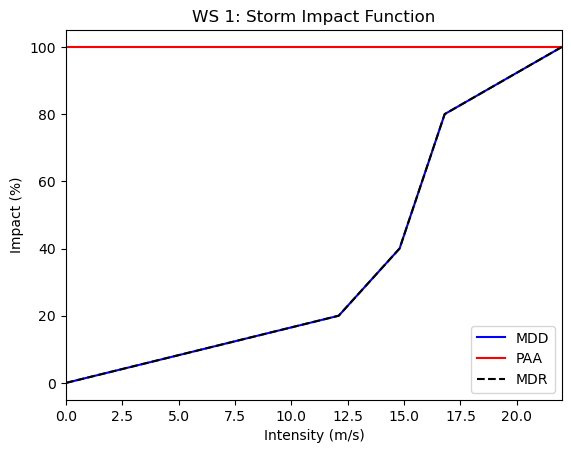

In [88]:
haz_dict["WS"]["impf_set"].plot()

(array([ 84., 360., 762., 774., 859., 676., 396., 256.,  79.,  14.]),
 array([ 5.19198362,  8.93819565, 12.68440769, 16.43061973, 20.17683177,
        23.92304381, 27.66925585, 31.41546789, 35.16167993, 38.90789197,
        42.654104  ]),
 <BarContainer object of 10 artists>)

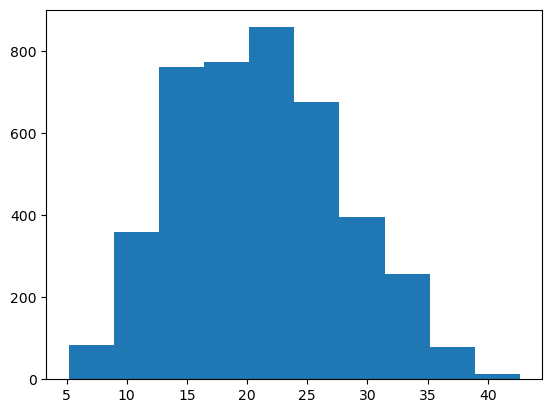

In [61]:
import matplotlib.pyplot as plt

plt.hist(haz_dict["WS"]["hazard"].intensity[:, 0].toarray())

## Define Function

In [86]:
from copy import deepcopy
import numpy as np
from climada.entity import Exposures
import climada.util.lines_polys_handler as u_lp

def comp_impact(haz_dict, exposure_template):
    """Function that Calculates the Cummulative EAI over multiple Hazard Types

    Args:
        haz_dict (_type_): Dictionary with Hazards and their impact functions
        exposure_template (_type_): A template of how the Exposure Set will look like

    Returns:
        GDF: Exposure as GDF with a new Column the Commulative EAI
    """
    
    ## Create an Exposure Map with only 1s
    exposure_eigen_gdf = deepcopy(exposure_template.gdf)
    exposure_eigen_gdf["value"] = 1
    exposure_eigen_poly = Exposures(exposure_eigen_gdf)
    
    ## Compute the EAI for each Hazard x Impact Function
    haz_eai = {}
    for haz_type, hazard in haz_dict.items():
        
        ## Automatic Computation using Polygons:
        # Dissagg: Splits the Exposure Value into Number of Pixels
        # Agg: Sums up all Damages
        # -> Same effect as not splitting Exposure and then taking a mean
        # SUM((exposure / N) * Impactvalue) = SUM (Exposure * Impactvalue) / N 
        
        impact = u_lp.calc_geom_impact(
            exp=exposure_eigen_poly,
            impf_set=hazard["impf_set"],
            haz=hazard["hazard"],
            res=0.05,
            to_meters=False,
            disagg_met=u_lp.DisaggMethod.DIV,
            disagg_val=None,
            agg_met=u_lp.AggMethod.SUM,
        )
        
        ## Clipping EAI at 1
        ## Make sure Hazard x Impactfunction make sense (not too many >1)
        eai_exp = np.clip(impact.eai_exp, a_min=0, a_max=1)
        haz_eai[haz_type] = eai_exp

    ## Aggregating multiple Hazards together:
    ## (1 - eai_WS) * (1 - eai_FL) * ...
    remaining_value = np.ones_like(eai_exp)
    for haz_type, eai in haz_eai.items():
        remaining_value *= (1 - eai)
    
    ## Going from Relative Remaining Value to EAI
    commulative_eai = 1 - remaining_value
    
    return commulative_eai

In [87]:
exposure = get_exposure(hazard_types=haz_list)

commulative_eai = comp_impact(haz_dict, exposure)

expsoure["commulative_eai"] = commulative_eai

exposure

2026-04-02 14:40:49,197 - climada.util.coordinates - WARNING - Distance to closest centroid is greater than 0.078125 degree for 3 coordinates.


/Users/arvedluetzen/.pyenv/versions/miniforge3-latest/envs/eth-fs2026-praktikum/lib/python3.12/site-packages/climada/util/lines_polys_handler.py:638: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
  group = gdf_pnts.groupby(axis=0, level=0)


TypeError: Since CLIMADA 2.0, Exposures objects are not subscriptable. Data fields of Exposures objects are accessed using the `gdf` attribute. For example, `expo['value']` is replaced by `expo.gdf['value']`.